📊 House Price Prediction and Analysis Project

This project is an end-to-end data analysis and machine learning practice project focused on understanding house price determinants and building predictive modeling skills.

The dataset used in this project is a synthetic house price dataset designed to simulate real-world data challenges, including missing values, duplicates, and feature inconsistencies.

🎯 Project Objectives

Perform data cleaning and preprocessing,
Conduct exploratory data analysis (EDA),
Apply feature engineering techniques,
Analyze relationships between housing features and price,
Build a regression model to predict house prices,
Evaluate model performance

🧠 Key Techniques Used

Data inspection and cleaning,Handling missing values and duplicates,Feature engineering,Aggregation and grouping analysis,Visualization using matplotlib,Encoding categorical variable,Machine learning regression modelin

📌 Tools & Libraries

Python,Pandas,NumPy,Matplotlib,Scikit-learn

In [10]:
# load the dataset
import pandas as pd
data = pd.read_csv('DataSet/house_price_synthetic_dataset (1).csv')


In [11]:
# inspect the dataset
data.head(5)

,house_id,area_sqft,bedrooms,bathrooms,neighborhood,year_built,garage_size,distance_city_center,house_condition,price
0,1,2048.0,3,2.0,NaN,1991,0.0,1.863147,Good,299498.287519
1,2,1730.0,2,2.0,Suburb,1971,2.0,3.536510,Fair,240544.491206
2,3,2123.0,3,NaN,Uptown,2017,2.0,12.730682,Excellent,250404.388236
3,4,2561.0,2,1.0,Riverside,1968,2.0,8.755637,Good,337383.811686
4,5,NaN,4,1.0,Downtown,2015,0.0,7.747427,Good,255988.190102


In [12]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              2020 non-null   int64  
 1   area_sqft             1920 non-null   float64
 2   bedrooms              2020 non-null   int64  
 3   bathrooms             1920 non-null   float64
 4   neighborhood          1919 non-null   str    
 5   year_built            2020 non-null   int64  
 6   garage_size           1920 non-null   float64
 7   distance_city_center  2020 non-null   float64
 8   house_condition       2020 non-null   str    
 9   price                 2020 non-null   float64
dtypes: float64(5), int64(3), str(2)
memory usage: 157.9 KB


In [ ]:
# understanding the shape of the dataset
data.shape

(2020, 10)

In [ ]:
# checking for missing value
data.isnull().sum().any()


np.True_

In [17]:
# checking the datatype
data.dtypes

house_id                  int64
area_sqft               float64
bedrooms                  int64
bathrooms               float64
neighborhood                str
year_built                int64
garage_size             float64
distance_city_center    float64
house_condition             str
price                   float64
dtype: object

In [18]:
data.columns

Index(['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'neighborhood',
       'year_built', 'garage_size', 'distance_city_center', 'house_condition',
       'price'],
      dtype='str')

In [24]:
# Data Cleaning
# checking for duplicates
data.duplicated().any()
data.drop_duplicates(inplace = True)

In [25]:
data.duplicated().any()

np.False_

In [28]:
data.isnull().sum()[data.isnull().sum()>0]

area_sqft       100
bathrooms       100
neighborhood    100
garage_size     100
dtype: int64

In [29]:
data['price'].isnull().any()

np.False_

In [ ]:
# chcking the datatype of the target variable
data['price'].dtype

dtype('float64')

<Axes: >

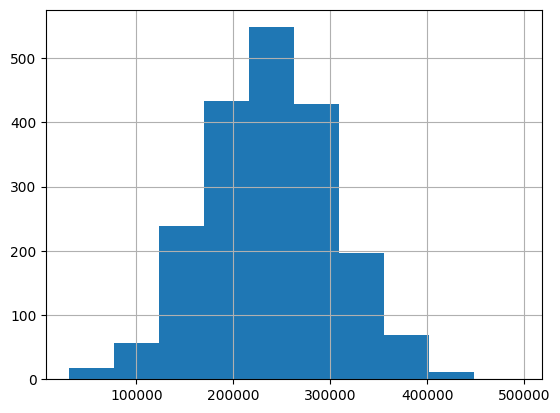

In [ ]:
# understanding the distribution of the target variable
data['price'].hist()

In [44]:
missing_count= data.isna().sum()
missing_percent=data.isna().mean()*100
pd.concat([missing_count,missing_percent],axis=1,keys=['Missing Count','Missing Percent'])

,Missing Count,Missing Percent
house_id,0,0.0
area_sqft,100,5.0
bedrooms,0,0.0
bathrooms,100,5.0
neighborhood,100,5.0
year_built,0,0.0
garage_size,100,5.0
distance_city_center,0,0.0
house_condition,0,0.0
price,0,0.0


In [49]:
data.isna().sum()[data.isna().sum()>0]

area_sqft       100
bathrooms       100
neighborhood    100
garage_size     100
dtype: int64

<Axes: >

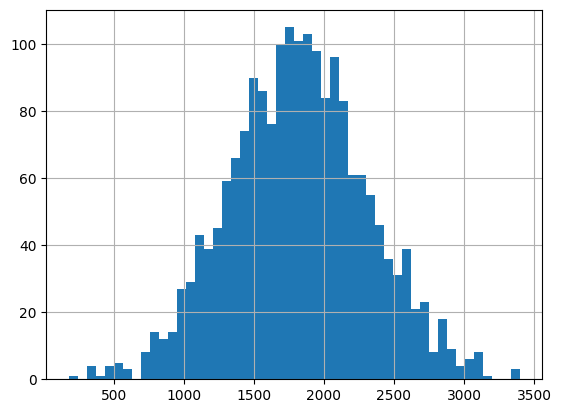

In [51]:
data['area_sqft'].hist(bins=50)


In [55]:
data.isna().sum()/len(data)*100 

house_id                0.0
area_sqft               5.0
bedrooms                0.0
bathrooms               5.0
neighborhood            5.0
year_built              0.0
garage_size             5.0
distance_city_center    0.0
house_condition         0.0
price                   0.0
dtype: float64

In [61]:
data[data.isna().any(axis=1)].shape

(377, 10)

In [62]:
data.isna().sum()[data.isna().sum()>0]

area_sqft       100
bathrooms       100
neighborhood    100
garage_size     100
dtype: int64

In [66]:
data['area_sqft'] = data['area_sqft'].fillna(data['area_sqft'].median(),inplace=True)

C:\Users\ABRISH\AppData\Local\Temp\ipykernel_11716\2582999359.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['area_sqft'] = data['area_sqft'].fillna(data['area_sqft'].median(),inplace=True)


In [67]:
data['area_sqft'].isna().sum()

np.int64(0)

In [69]:
data['bathrooms'] = data['bathrooms'].fillna(data['bathrooms'].median(),inplace=True)

C:\Users\ABRISH\AppData\Local\Temp\ipykernel_11716\1008482408.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['bathrooms'] = data['bathrooms'].fillna(data['bathrooms'].median(),inplace=True)


In [71]:
data['bathrooms'].isna().sum()

np.int64(0)

In [74]:
data['neighborhood'].head()

0          NaN
1       Suburb
2       Uptown
3    Riverside
4     Downtown
Name: neighborhood, dtype: str

In [75]:
data['neighborhood'].mode()

0    Downtown
Name: neighborhood, dtype: str

In [80]:
data['neighborhood'] = data['neighborhood'].fillna('Unknown',inplace=True)

C:\Users\ABRISH\AppData\Local\Temp\ipykernel_11716\1427408525.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['neighborhood'] = data['neighborhood'].fillna('Unknown',inplace=True)


In [81]:
data['neighborhood']

0         Unknown
1          Suburb
2          Uptown
3       Riverside
4        Downtown
          ...    
1995       Suburb
1996      OldTown
1997       Suburb
1998       Suburb
1999    Riverside
Name: neighborhood, Length: 2000, dtype: str

In [82]:
data['neighborhood'].isna().sum()

np.int64(0)

In [87]:
data['garage_size'].value_counts()

garage_size
1.0    760
0.0    557
2.0    391
3.0    192
Name: count, dtype: int64

In [90]:
data['garage_size'] = data['garage_size'].fillna(0,inplace=True)


C:\Users\ABRISH\AppData\Local\Temp\ipykernel_11716\1684061162.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['garage_size'] = data['garage_size'].fillna(0,inplace=True)


In [91]:
data['garage_size'].isna().sum()

np.int64(0)

In [92]:
data.isna().sum()

house_id                0
area_sqft               0
bedrooms                0
bathrooms               0
neighborhood            0
year_built              0
garage_size             0
distance_city_center    0
house_condition         0
price                   0
neighborhood            0
garage-size             0
dtype: int64

In [93]:
# checking for outliers
data['price'].describe()

count      2000.000000
mean     237928.474797
std       65846.847971
min       30000.000000
25%      191712.595304
50%      238939.953160
75%      280925.270806
max      495267.117115
Name: price, dtype: float64

In [94]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              2000 non-null   int64  
 1   area_sqft             2000 non-null   float64
 2   bedrooms              2000 non-null   int64  
 3   bathrooms             2000 non-null   float64
 4   neighborhood          2000 non-null   str    
 5   year_built            2000 non-null   int64  
 6   garage_size           2000 non-null   float64
 7   distance_city_center  2000 non-null   float64
 8   house_condition       2000 non-null   str    
 9   price                 2000 non-null   float64
 10  neighborhood          2000 non-null   str    
 11  garage-size           2000 non-null   float64
dtypes: float64(6), int64(3), str(3)
memory usage: 187.6 KB


In [95]:
data.shape

(2000, 12)

In [96]:
data.columns

Index(['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'neighborhood',
       'year_built', 'garage_size', 'distance_city_center', 'house_condition',
       'price', 'neighborhood ', 'garage-size'],
      dtype='str')

In [99]:
data = data.loc[:, ~data.columns.duplicated()]

In [100]:
data.shape

(2000, 12)

In [103]:
data.columns.duplicated()

array([False, False, False, False, False, False, False, False, False,
       False, False, False])

In [104]:
data.head(1)

,house_id,area_sqft,bedrooms,bathrooms,neighborhood,year_built,garage_size,distance_city_center,house_condition,price,neighborhood,garage-size
0,1,2048.0,3,2.0,Unknown,1991,0.0,1.863147,Good,299498.287519,Unknown,0.0


In [117]:
data.columns.duplicated().any()

np.False_

In [118]:
data.columns.tolist()

['house_id',
 'area_sqft',
 'bedrooms',
 'bathrooms',
 'neighborhood',
 'year_built',
 'garage_size',
 'distance_city_center',
 'house_condition',
 'price',
 'neighborhood ',
 'garage-size']

In [119]:
data.columns = data.columns.str.strip()

In [120]:
data.shape

(2000, 12)

In [121]:
data.columns.tolist()

['house_id',
 'area_sqft',
 'bedrooms',
 'bathrooms',
 'neighborhood',
 'year_built',
 'garage_size',
 'distance_city_center',
 'house_condition',
 'price',
 'neighborhood',
 'garage-size']

In [122]:
data.rename(columns={'garage-size':'garage_size'}, inplace=True)

In [125]:
data = data.loc[:, ~data.columns.duplicated(keep="first")]

In [128]:
data.shape

(2000, 10)

In [131]:

data.duplicated().sum()

np.int64(0)

In [132]:
data.isna().sum()

house_id                0
area_sqft               0
bedrooms                0
bathrooms               0
neighborhood            0
year_built              0
garage_size             0
distance_city_center    0
house_condition         0
price                   0
dtype: int64

In [133]:
# checking for outliers
data['price'].describe()

count      2000.000000
mean     237928.474797
std       65846.847971
min       30000.000000
25%      191712.595304
50%      238939.953160
75%      280925.270806
max      495267.117115
Name: price, dtype: float64

In [134]:
q1 = data['price'].quantile(0.25)
q3 = data['price'].quantile(0.75)
iqr = q3 - q1   
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = data[(data['price'] < lower_bound) | (data['price'] > upper_bound)]
outliers.shape

(10, 10)

In [135]:
len(outliers) / len(data) * 100

0.5

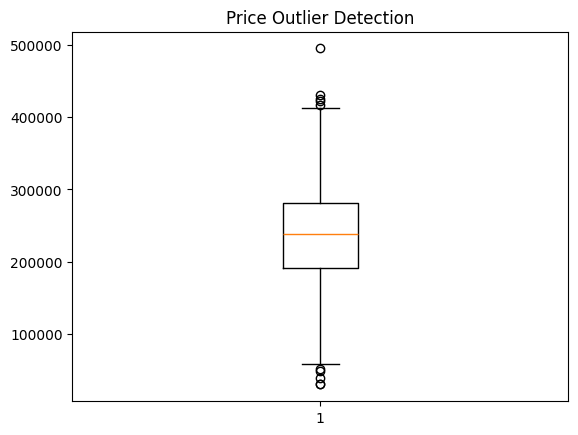

In [ ]:

import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(data["price"])
plt.title("Price Outlier Detection")
plt.show()

<Axes: >

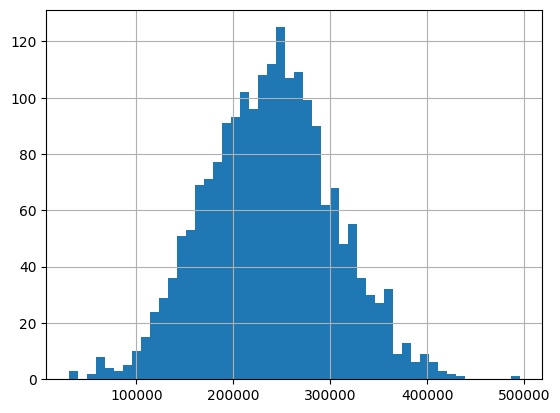

In [137]:
data['price'].hist(bins=50)

In [138]:
import numpy as np
data["price"] = np.log1p(data["price"])

In [139]:
outliers.shape

(10, 10)

In [140]:
data.head()

,house_id,area_sqft,bedrooms,bathrooms,neighborhood,year_built,garage_size,distance_city_center,house_condition,price
0,1,2048.0,3,2.0,Unknown,1991,0.0,1.863147,Good,12.609867
1,2,1730.0,2,2.0,Suburb,1971,2.0,3.536510,Fair,12.390665
2,3,2123.0,3,2.0,Uptown,2017,2.0,12.730682,Excellent,12.430836
3,4,2561.0,2,1.0,Riverside,1968,2.0,8.755637,Good,12.728979
4,5,1818.0,4,1.0,Downtown,2015,0.0,7.747427,Good,12.452890


In [141]:
data['price'].unique()

array([12.60986732, 12.3906645 , 12.43083644, ..., 12.31571275,
       12.32720545, 12.05717668], shape=(1999,))

{'whiskers': [<matplotlib.lines.Line2D at 0x213a833b440>,
 'caps': [<matplotlib.lines.Line2D at 0x213a8568710>,
 'boxes': [<matplotlib.lines.Line2D at 0x213a717bd40>],
 'medians': [<matplotlib.lines.Line2D at 0x213a8568080>],
 'fliers': [<matplotlib.lines.Line2D at 0x213a8568950>],
 'means': []}

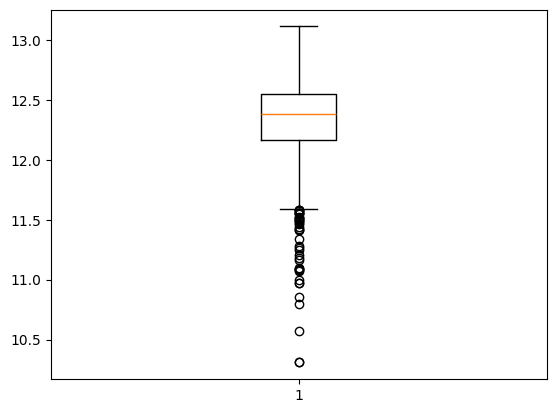

In [142]:
plt.figure()
plt.boxplot(data["price"])

<Axes: >

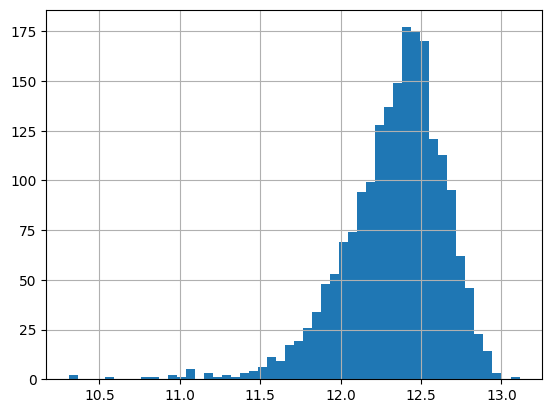

In [143]:
data['price'].hist(bins=50)

In [144]:
data['price'].describe()

count    2000.000000
mean       12.335704
std         0.313313
min        10.308986
25%        12.163758
50%        12.383972
75%        12.545847
max        13.112855
Name: price, dtype: float64

In [145]:
numeric_df = data.select_dtypes(include=np.number)

In [146]:
corr_matrix = numeric_df.corr()

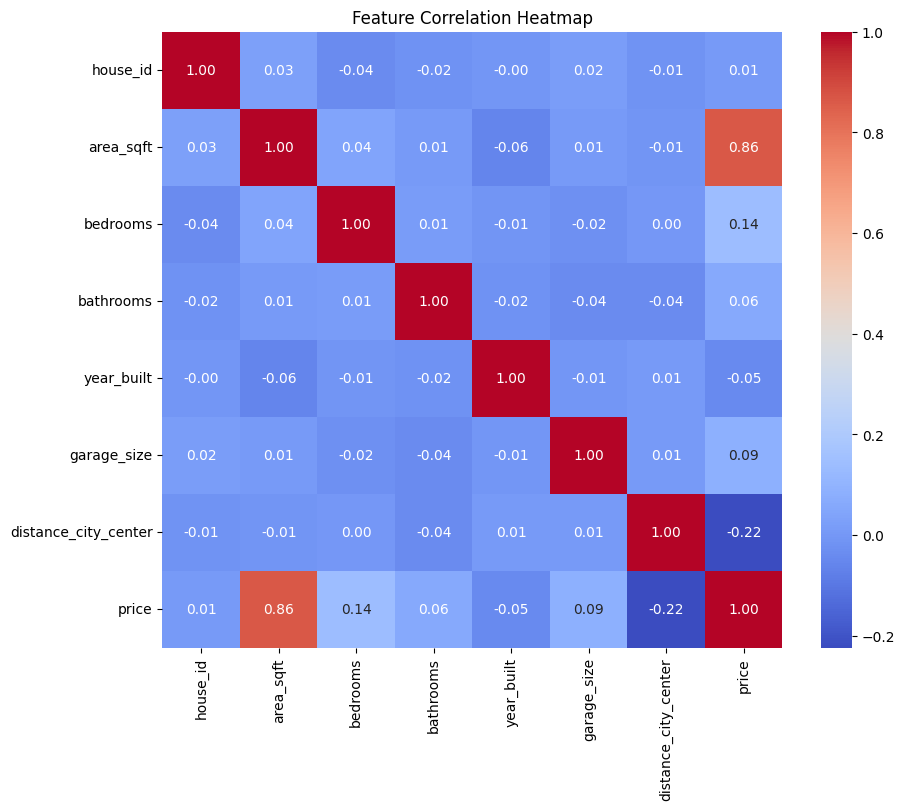

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [148]:
# Sort Features by Price Correlation
corr_price = corr_matrix["price"].sort_values(ascending=False)

print(corr_price)

price                   1.000000
area_sqft               0.862816
bedrooms                0.136396
garage_size             0.087110
bathrooms               0.060072
house_id                0.010501
year_built             -0.046158
distance_city_center   -0.223227
Name: price, dtype: float64
